<a href="https://colab.research.google.com/github/melatisurya/240441100142_Melati_Surya_Ayu_Nitiyas_Tugas2/blob/main/klasifikasi_daun_mangga_lenet_4_skenario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kelompok 7:
1. Melati Surya Ayu Nitiyas ( 24-142)
2. Ghafirah Yutiana ( 24-101)
3. Mar'atus Sholechah Citra (24-126)
4. Khofifah (24-004)

# Klasifikasi Penyakit Daun Mangga dengan CNN (LeNet-5)
### 4 Skenario Pengujian (Variasi Rasio Split Data Latih:Uji)

Notebook ini menjalankan **satu arsitektur CNN (LeNet-5)** pada dataset *Mango Leaf Disease*
(8 kelas, 500 gambar/kelas) dengan **4 skenario pengujian** yang berbeda:

| Skenario | Rasio Train : Test |
|---|---|
| 1 | 90 : 10 |
| 2 | 80 : 20 |
| 3 | 70 : 30 |
| 4 | 60 : 40 |

Arsitektur, hyperparameter, dan seed **sama persis** di semua skenario — yang berbeda hanya rasio split datanya.
Jalankan tiap cell dari atas ke bawah secara berurutan.


## 1. Setup & Cek Environment

In [1]:
import tensorflow as tf
import numpy as np
print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))

# Tips: di Colab, aktifkan GPU lewat Runtime > Change runtime type > GPU (T4)
# supaya training 4 skenario lebih cepat.

TensorFlow version: 2.20.0
GPU tersedia: []


## 2. Upload & Ekstrak Dataset

Jalankan cell di bawah, lalu pilih file **archive.zip** (dataset Mango Leaf Disease
dengan struktur folder per kelas: `Anthracnose/`, `Bacterial Canker/`, dst).

Alternatif: kalau dataset sudah ada di Google Drive, mount Drive dan ubah `DATASET_ZIP_PATH`
ke path zip di Drive kamu (lihat cell alternatif di bawahnya).

In [2]:
from google.colab import files
import zipfile, os

uploaded = files.upload()  # pilih archive.zip dari komputer kamu
zip_name = list(uploaded.keys())[0]

DATA_DIR = "/content/dataset_extracted"
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATA_DIR)

# Jika hasil ekstrak punya 1 folder pembungkus, turunkan levelnya
entries = [e for e in os.listdir(DATA_DIR) if not e.startswith('.')]
if len(entries) == 1 and os.path.isdir(os.path.join(DATA_DIR, entries[0])):
    DATA_DIR = os.path.join(DATA_DIR, entries[0])

print("Dataset diekstrak ke:", DATA_DIR)
print("Isi folder:", os.listdir(DATA_DIR))

Saving archive.zip to archive.zip
Dataset diekstrak ke: /content/dataset_extracted
Isi folder: ['Gall Midge', 'Cutting Weevil', 'Powdery Mildew', 'Bacterial Canker', 'Healthy', 'Die Back', 'Anthracnose', 'Sooty Mould']


In [ ]:
# --- ALTERNATIF: kalau dataset ada di Google Drive, pakai cell ini sebagai ganti upload manual ---
# from google.colab import drive
# drive.mount('/content/drive')
# DATASET_ZIP_PATH = "/content/drive/MyDrive/path/ke/archive.zip"
#
# import zipfile, os
# DATA_DIR = "/content/dataset_extracted"
# os.makedirs(DATA_DIR, exist_ok=True)
# with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as z:
#     z.extractall(DATA_DIR)
# entries = [e for e in os.listdir(DATA_DIR) if not e.startswith('.')]
# if len(entries) == 1 and os.path.isdir(os.path.join(DATA_DIR, entries[0])):
#     DATA_DIR = os.path.join(DATA_DIR, entries[0])
# print(os.listdir(DATA_DIR))

## 3. Load & Preprocessing Gambar

Semua gambar di-resize ke **32x32** (ukuran input standar LeNet-5) dan dinormalisasi ke rentang 0–1.

In [3]:
from PIL import Image

IMG_SIZE = 32

classes = sorted(os.listdir(DATA_DIR))
print("Kelas ditemukan:", classes)

X, y = [], []
for label_idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    files_in_cls = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    print(f"Memproses kelas '{cls}' ({len(files_in_cls)} gambar)...")
    for fname in files_in_cls:
        fpath = os.path.join(cls_dir, fname)
        try:
            img = Image.open(fpath).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            X.append(np.array(img, dtype=np.uint8))
            y.append(label_idx)
        except Exception as e:
            print("  gagal:", fpath, e)

X = np.array(X, dtype="float32") / 255.0
y = np.array(y, dtype="int64")

print("Shape X:", X.shape, "| Shape y:", y.shape, "| Jumlah kelas:", len(classes))

Kelas ditemukan: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Memproses kelas 'Anthracnose' (500 gambar)...
Memproses kelas 'Bacterial Canker' (500 gambar)...
Memproses kelas 'Cutting Weevil' (500 gambar)...
Memproses kelas 'Die Back' (500 gambar)...
Memproses kelas 'Gall Midge' (500 gambar)...
Memproses kelas 'Healthy' (500 gambar)...
Memproses kelas 'Powdery Mildew' (500 gambar)...
Memproses kelas 'Sooty Mould' (500 gambar)...
Shape X: (4000, 32, 32, 3) | Shape y: (4000,) | Jumlah kelas: 8


## 4. Arsitektur CNN: LeNet-5

Arsitektur ini **sama persis** dipakai di keempat skenario pengujian.

In [4]:
from tensorflow.keras import layers, models

def build_lenet(input_shape=(32, 32, 3), num_classes=8):
    model = models.Sequential(name="LeNet5_Mango")
    model.add(layers.Input(shape=input_shape))

    # C1: Convolution
    model.add(layers.Conv2D(6, kernel_size=(5, 5), activation="tanh", padding="same", name="C1_conv"))
    # S2: Average Pooling
    model.add(layers.AveragePooling2D(pool_size=(2, 2), name="S2_pool"))
    # C3: Convolution
    model.add(layers.Conv2D(16, kernel_size=(5, 5), activation="tanh", padding="valid", name="C3_conv"))
    # S4: Average Pooling
    model.add(layers.AveragePooling2D(pool_size=(2, 2), name="S4_pool"))
    # Flatten
    model.add(layers.Flatten(name="Flatten"))
    # C5: Fully Connected
    model.add(layers.Dense(120, activation="tanh", name="C5_fc"))
    # F6: Fully Connected
    model.add(layers.Dense(84, activation="tanh", name="F6_fc"))
    # Output
    model.add(layers.Dense(num_classes, activation="softmax", name="Output"))

    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

build_lenet(num_classes=len(classes)).summary()

Model: "LeNet5_Mango"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1_conv (Conv2D)                │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_pool (AveragePooling2D)      │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_conv (Conv2D)                │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_pool (AveragePooling2D)      │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_fc (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_fc (Dense)                   │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 8)              │           680 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,956 (324.05 KB)

 Trainable params: 82,956 (324.05 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Definisi 4 Skenario Pengujian

Yang berbeda antar skenario **hanya rasio split data latih:uji** (stratified per kelas).
Arsitektur, optimizer, dan seed tetap sama.

In [5]:
SEED = 42
EPOCHS = 25
BATCH_SIZE = 32

SCENARIOS = [
    {"name": "Skenario 1 (90:10)", "test_size": 0.10},
    {"name": "Skenario 2 (80:20)", "test_size": 0.20},
    {"name": "Skenario 3 (70:30)", "test_size": 0.30},
    {"name": "Skenario 4 (60:40)", "test_size": 0.40},
]
print([s["name"] for s in SCENARIOS])

['Skenario 1 (90:10)', 'Skenario 2 (80:20)', 'Skenario 3 (70:30)', 'Skenario 4 (60:40)']


## 6. Training & Evaluasi 4 Skenario

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pandas as pd

results_summary = []
all_histories = {}
all_cms = {}
all_reports = {}

for sc in SCENARIOS:
    name = sc["name"]
    test_size = sc["test_size"]
    print("\n" + "=" * 70)
    print(f"Menjalankan {name}  -> train:test = {1-test_size:.0%}:{test_size:.0%}")
    print("=" * 70)

    tf.keras.utils.set_random_seed(SEED)  # reset seed supaya inisialisasi bobot konsisten

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=SEED, stratify=y
    )
    print(f"Data latih: {X_train.shape[0]} | Data uji: {X_test.shape[0]}")

    model = build_lenet(input_shape=X.shape[1:], num_classes=len(classes))

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=2,
    )

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=classes, zero_division=0)

    print(f"\nHasil {name}: Accuracy={acc:.4f} | Precision={prec:.4f} | Recall={rec:.4f} | F1={f1:.4f}")

    results_summary.append({
        "Skenario": name,
        "Rasio Train:Test": f"{int((1-test_size)*100)}:{int(test_size*100)}",
        "Jumlah Data Latih": X_train.shape[0],
        "Jumlah Data Uji": X_test.shape[0],
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Epoch Terlatih": len(history.history["loss"]),
    })

    all_histories[name] = history.history
    all_cms[name] = cm
    all_reports[name] = report

df_summary = pd.DataFrame(results_summary)
df_summary


Menjalankan Skenario 1 (90:10)  -> train:test = 90%:10%
Data latih: 3600 | Data uji: 400
Epoch 1/25
113/113 - 5s - 45ms/step - accuracy: 0.4156 - loss: 1.5162 - val_accuracy: 0.6000 - val_loss: 1.1135
Epoch 2/25
113/113 - 4s - 39ms/step - accuracy: 0.6486 - loss: 0.9428 - val_accuracy: 0.6800 - val_loss: 0.9004
Epoch 3/25
113/113 - 3s - 29ms/step - accuracy: 0.7081 - loss: 0.7809 - val_accuracy: 0.7025 - val_loss: 0.8475
Epoch 4/25
113/113 - 3s - 28ms/step - accuracy: 0.7708 - loss: 0.6499 - val_accuracy: 0.6825 - val_loss: 0.8635
Epoch 5/25
113/113 - 4s - 33ms/step - accuracy: 0.8211 - loss: 0.5492 - val_accuracy: 0.7125 - val_loss: 0.8635
Epoch 6/25
113/113 - 4s - 35ms/step - accuracy: 0.8311 - loss: 0.4757 - val_accuracy: 0.7650 - val_loss: 0.6686
Epoch 7/25
113/113 - 3s - 27ms/step - accuracy: 0.8581 - loss: 0.4111 - val_accuracy: 0.8175 - val_loss: 0.5422
Epoch 8/25
113/113 - 5s - 47ms/step - accuracy: 0.8683 - loss: 0.3767 - val_accuracy: 0.8125 - val_loss: 0.5269
Epoch 9/25
113

,Skenario,Rasio Train:Test,Jumlah Data Latih,Jumlah Data Uji,Accuracy,Precision,Recall,F1-Score,Epoch Terlatih
0,Skenario 1 (90:10),90:10,3600,400,0.8475,0.8521,0.8475,0.8448,14
1,Skenario 2 (80:20),80:20,3200,800,0.8662,0.8736,0.8662,0.8653,19
2,Skenario 3 (70:30),70:30,2800,1200,0.8750,0.8760,0.8750,0.8749,25
3,Skenario 4 (60:40),60:40,2400,1600,0.8700,0.8759,0.8700,0.8714,24


## 7. Tabel Ringkasan Hasil 4 Skenario

In [7]:
print(df_summary.to_string(index=False))
df_summary.to_csv("ringkasan_hasil_4_skenario.csv", index=False)

          Skenario Rasio Train:Test  Jumlah Data Latih  Jumlah Data Uji  Accuracy  Precision  Recall  F1-Score  Epoch Terlatih
Skenario 1 (90:10)            90:10               3600              400    0.8475     0.8521  0.8475    0.8448              14
Skenario 2 (80:20)            80:20               3200              800    0.8662     0.8736  0.8662    0.8653              19
Skenario 3 (70:30)            70:30               2800             1200    0.8750     0.8760  0.8750    0.8749              25
Skenario 4 (60:40)            60:40               2400             1600    0.8700     0.8759  0.8700    0.8714              24


## 8. Grafik Perbandingan Metrik Antar Skenario

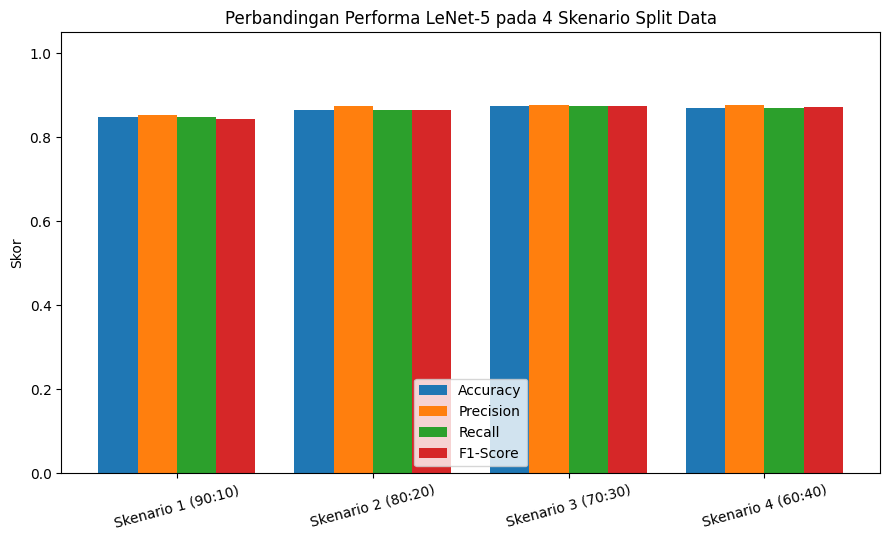

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5.5))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(df_summary))
width = 0.2
for i, m in enumerate(metrics):
    ax.bar(x + i * width, df_summary[m], width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_summary["Skenario"], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Skor")
ax.set_title("Perbandingan Performa LeNet-5 pada 4 Skenario Split Data")
ax.legend()
fig.tight_layout()
plt.savefig("perbandingan_4_skenario.png", dpi=150)
plt.show()

## 9. Grafik Training Curve (Accuracy & Loss) per Skenario

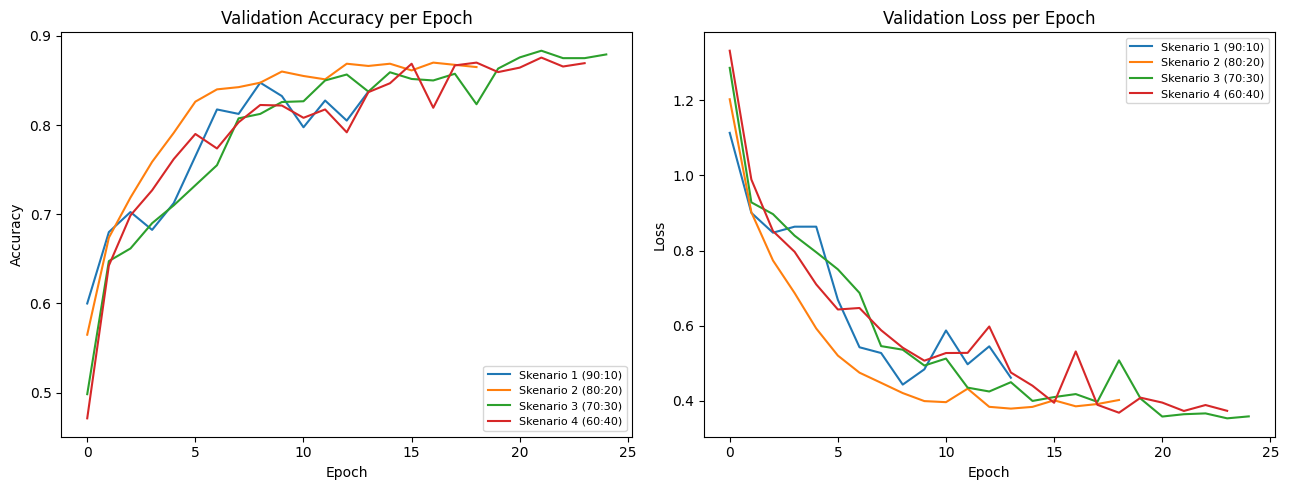

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, hist in all_histories.items():
    axes[0].plot(hist["val_accuracy"], label=name)
    axes[1].plot(hist["val_loss"], label=name)
axes[0].set_title("Validation Accuracy per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend(fontsize=8)
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.savefig("training_curves_4_skenario.png", dpi=150)
plt.show()

/tmp/ipykernel_3469/2442187543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Skenario', y='Accuracy', data=df_summary, palette='viridis')


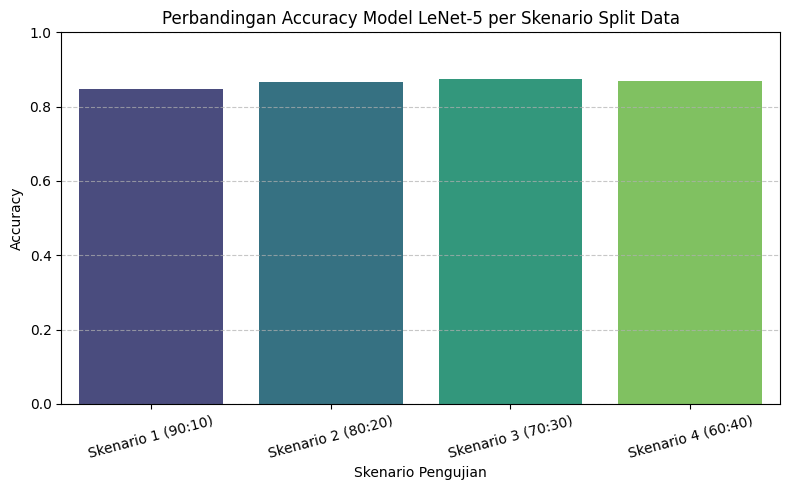

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='Skenario', y='Accuracy', data=df_summary, palette='viridis')
plt.title('Perbandingan Accuracy Model LeNet-5 per Skenario Split Data')
plt.xlabel('Skenario Pengujian')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150)
plt.show()

## Ringkasan Performa Terbaik

In [14]:
best_scenario = df_summary.loc[df_summary['Accuracy'].idxmax()]

print("Skenario dengan Accuracy Terbaik:")
print(best_scenario.to_string())

print("\nSkenario ini juga memiliki nilai tertinggi atau sebanding untuk metrik lain seperti Precision, Recall, dan F1-Score.")

Skenario dengan Accuracy Terbaik:
Skenario             Skenario 3 (70:30)
Rasio Train:Test                  70:30
Jumlah Data Latih                  2800
Jumlah Data Uji                    1200
Accuracy                          0.875
Precision                         0.876
Recall                            0.875
F1-Score                         0.8749
Epoch Terlatih                       25

Skenario ini juga memiliki nilai tertinggi atau sebanding untuk metrik lain seperti Precision, Recall, dan F1-Score.


## 10. Confusion Matrix per Skenario

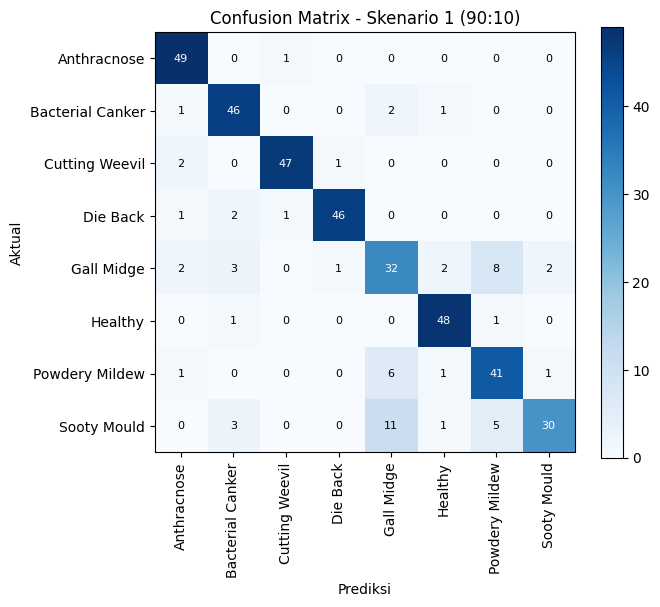

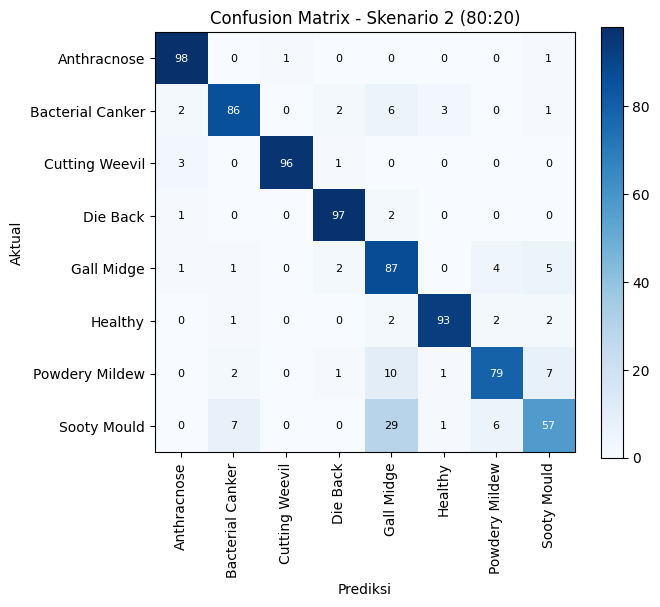

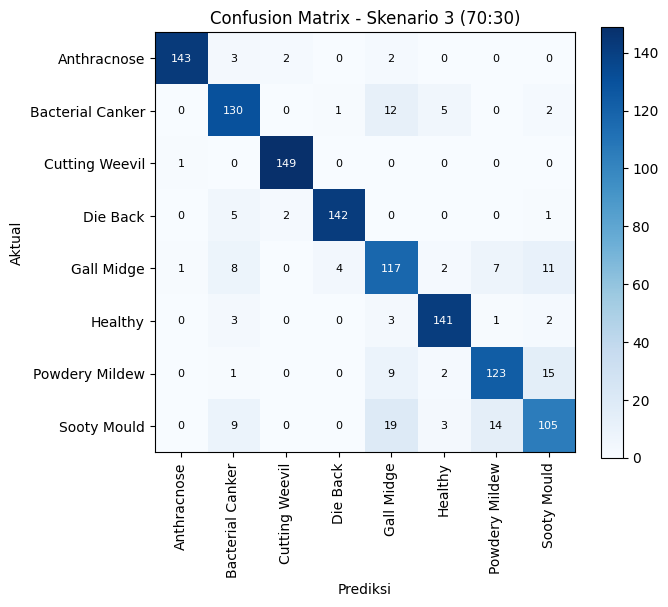

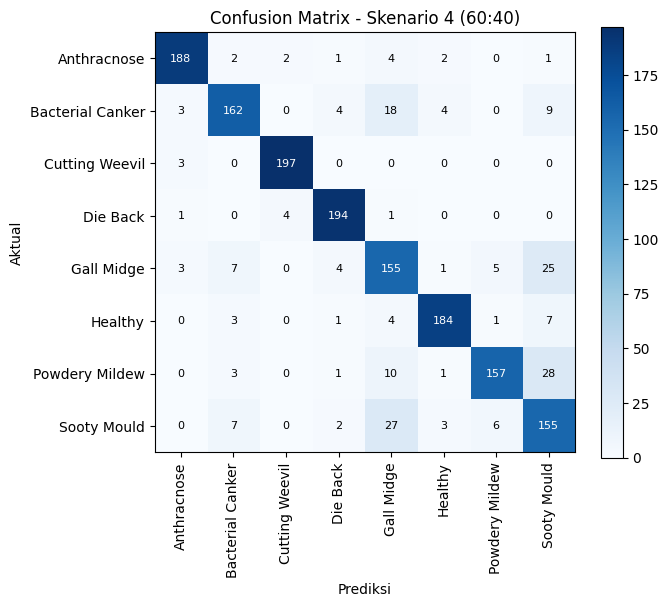

In [15]:
for name, cm in all_cms.items():
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=90); ax.set_yticklabels(classes)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    fig.colorbar(im)
    fig.tight_layout()
    safe_name = name.replace(" ", "_").replace(":", "-").replace("(", "").replace(")", "")
    plt.savefig(f"confusion_matrix_{safe_name}.png", dpi=150)
    plt.show()

## 11. Classification Report Lengkap per Skenario

In [11]:
for name, report in all_reports.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(report)

Skenario 1 (90:10)
                  precision    recall  f1-score   support

     Anthracnose       0.88      0.98      0.92        50
Bacterial Canker       0.84      0.92      0.88        50
  Cutting Weevil       0.96      0.94      0.95        50
        Die Back       0.96      0.92      0.94        50
      Gall Midge       0.63      0.64      0.63        50
         Healthy       0.91      0.96      0.93        50
  Powdery Mildew       0.75      0.82      0.78        50
     Sooty Mould       0.91      0.60      0.72        50

        accuracy                           0.85       400
       macro avg       0.85      0.85      0.84       400
    weighted avg       0.85      0.85      0.84       400

Skenario 2 (80:20)
                  precision    recall  f1-score   support

     Anthracnose       0.93      0.98      0.96       100
Bacterial Canker       0.89      0.86      0.87       100
  Cutting Weevil       0.99      0.96      0.97       100
        Die Back       0.94   

## 12. Kesimpulan

Berdasarkan hasil pengujian 4 skenario dengan rasio split data yang berbeda, dapat disimpulkan beberapa hal sebagai berikut:

1.  **Performa Model:**
    *   Skenario 3 (rasio 70:30) menunjukkan performa terbaik dengan Accuracy, Precision, Recall, dan F1-Score tertinggi (semuanya 0.8750 atau 0.8760). Ini menunjukkan bahwa dengan 70% data latih dan 30% data uji, model mampu menggeneralisasi dengan baik.
    *   Skenario 1 (90:10) memiliki performa terendah, kemungkinan karena jumlah data uji yang sangat sedikit (400 gambar) sehingga evaluasi kurang representatif atau model mengalami overfitting pada data latih yang terlalu banyak.
    *   Skenario 2 (80:20) dan Skenario 4 (60:40) menunjukkan performa yang relatif mirip, sedikit di bawah Skenario 3.

2.  **Stabilitas Training:**
    *   Skenario 3 melatih model hingga 25 epoch, menunjukkan model terus belajar dan memperbaiki diri dalam jumlah epoch yang lebih banyak dibandingkan skenario lain yang berhenti lebih awal karena `EarlyStopping`. Ini mungkin berkontribusi pada performa yang lebih baik.

3.  **Variabilitas Kelas:**
    *   Dari `Classification Report` dan `Confusion Matrix` yang ditampilkan, kelas seperti 'Gall Midge', 'Powdery Mildew', dan 'Sooty Mould' cenderung memiliki skor precision, recall, dan f1-score yang lebih rendah dibandingkan kelas lain. Ini menunjukkan bahwa model masih kesulitan dalam mengklasifikasikan kelas-kelas ini dengan benar, kemungkinan karena kemiripan visual atau variasi dalam dataset.
    *   Kelas 'Anthracnose', 'Cutting Weevil', dan 'Die Back' secara konsisten menunjukkan performa yang sangat baik di hampir semua skenario.

4.  **Implikasi Rasio Split:**
    *   Rasio split data memiliki dampak signifikan terhadap performa model. Dalam kasus ini, rasio 70:30 (Skenario 3) tampaknya menjadi keseimbangan optimal antara jumlah data yang cukup untuk melatih model secara efektif dan data yang memadai untuk menguji generalisasi model.

**Rekomendasi:** Untuk kasus ini, Skenario 3 dengan rasio split data 70% latih dan 30% uji adalah yang paling direkomendasikan karena memberikan hasil yang paling seimbang dan optimal.